# Projeto Fuzzy – Medição de Disposição Humana

## Objetivo
Este projeto propõe um sistema fuzzy autoral para **estimar o nível de disposição de uma pessoa** ao longo do dia, com base em fatores do cotidiano.

A escolha da lógica fuzzy se justifica porque esse problema envolve **transições graduais e subjetivas**. Em um modelo rígido, uma pessoa com 5,9 horas de sono poderia ser tratada de forma totalmente diferente de outra com 6 horas, mesmo estando em situações muito parecidas. Com a lógica fuzzy, essa transição passa a ser modelada de forma mais natural.

O projeto foi organizado em **duas versões**:
- **V1:** modelo inicial, mais simples, com 3 variáveis de entrada;
- **V2:** modelo refinado, com 5 variáveis de entrada e maior aderência à realidade.

Dessa forma, além de apresentar o sistema final, também mostramos a **evolução do projeto**, conforme solicitado na proposta.

## Justificativa dos universos de discurso e rótulos linguísticos

### Entradas
- **Sono (0 a 12 horas):** cobre desde privação severa até excesso de sono.
  - curto
  - adequado
  - prolongado

- **Qualidade do sono (0 a 10):** escala subjetiva simples e intuitiva para autoavaliação.
  - ruim
  - regular
  - boa

- **Esforço físico (0 a 100):** representa intensidade percentual aproximada da carga física do dia.
  - leve
  - moderada
  - intensa

- **Alimentação (0 a 10):** representa a qualidade da alimentação ao longo do dia.
  - ruim
  - regular
  - boa

- **Estresse (0 a 10):** representa o nível percebido de estresse.
  - baixo
  - médio
  - alto

### Saída
- **Disposição (0 a 100):** representa o nível de energia e disposição estimado pelo sistema.
  - baixa
  - média
  - alta

Os rótulos linguísticos foram escolhidos para representar faixas semanticamente compreensíveis e coerentes com o problema.

In [ ]:
!pip -q install numpy matplotlib scikit-fuzzy pandas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Versão 1 (V1) – Modelo Inicial

A **V1** foi criada para validar a ideia principal do projeto com uma estrutura mais simples. Nessa primeira versão, foram consideradas apenas três variáveis de entrada:

- sono;
- qualidade do sono;
- esforço físico.

A saída do sistema continua sendo a **disposição**.

Essa versão foi importante para testar se a lógica fuzzy era adequada ao problema antes de ampliar o modelo.

## V1 – Definição formal das variáveis e dos universos de discurso

In [ ]:
# Universos de discurso da V1
sono_v1 = ctrl.Antecedent(np.arange(0, 13, 1), 'sono')
qualidade_v1 = ctrl.Antecedent(np.arange(0, 11, 1), 'qualidade')
esforco_v1 = ctrl.Antecedent(np.arange(0, 101, 1), 'esforco')
disposicao_v1 = ctrl.Consequent(np.arange(0, 101, 1), 'disposicao')

## V1 – Construção das funções de pertinência

Na V1, utilizamos funções **trapezoidais** e **triangulares**.  
As trapezoidais foram adotadas para representar regiões mais estáveis, enquanto as triangulares foram usadas para valores centrais.

In [ ]:
# Sono
sono_v1['curto'] = fuzz.trapmf(sono_v1.universe, [0, 0, 4, 6])
sono_v1['adequado'] = fuzz.trimf(sono_v1.universe, [5, 8, 10])
sono_v1['prolongado'] = fuzz.trapmf(sono_v1.universe, [9, 11, 12, 12])

# Qualidade do sono
qualidade_v1['ruim'] = fuzz.trapmf(qualidade_v1.universe, [0, 0, 3, 5])
qualidade_v1['regular'] = fuzz.trimf(qualidade_v1.universe, [4, 6, 8])
qualidade_v1['boa'] = fuzz.trapmf(qualidade_v1.universe, [7, 8, 10, 10])

# Esforço físico
esforco_v1['leve'] = fuzz.trapmf(esforco_v1.universe, [0, 0, 25, 45])
esforco_v1['moderada'] = fuzz.trimf(esforco_v1.universe, [30, 50, 70])
esforco_v1['intensa'] = fuzz.trapmf(esforco_v1.universe, [60, 80, 100, 100])

# Disposição
disposicao_v1['baixa'] = fuzz.trapmf(disposicao_v1.universe, [0, 0, 25, 45])
disposicao_v1['media'] = fuzz.trimf(disposicao_v1.universe, [35, 55, 75])
disposicao_v1['alta'] = fuzz.trapmf(disposicao_v1.universe, [65, 80, 100, 100])

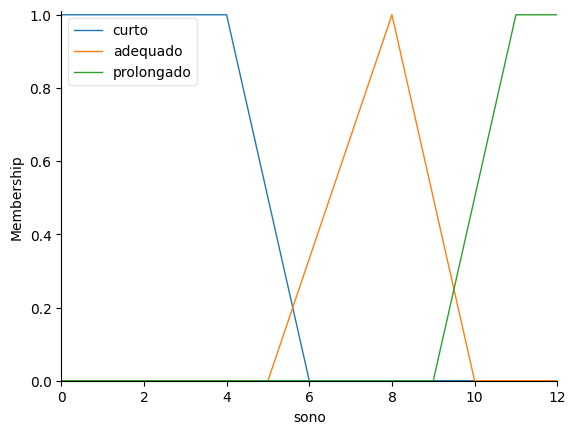

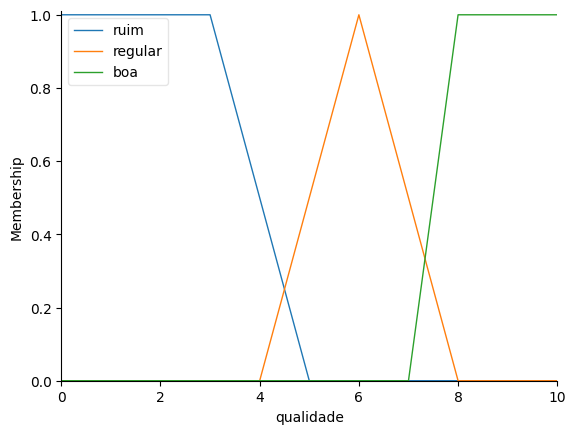

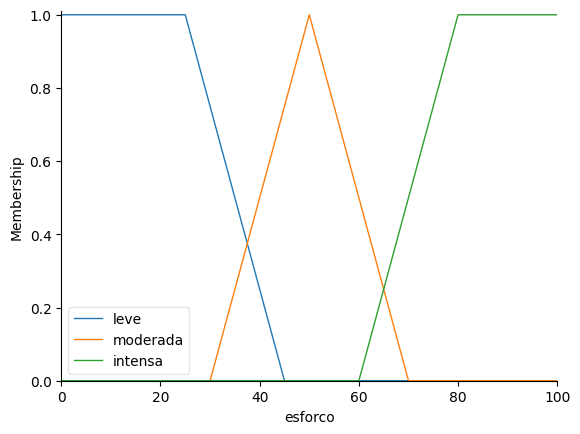

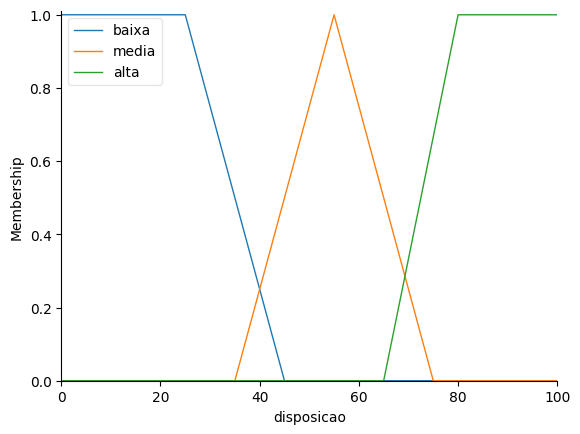

In [ ]:
# Visualização das funções de pertinência da V1
for var in [sono_v1, qualidade_v1, esforco_v1, disposicao_v1]:
    var.view()
    plt.show()

## V1 – Base de regras fuzzy

A V1 possui uma base de regras mais enxuta, suficiente para validar o comportamento geral do sistema. Como essa era uma versão inicial, o objetivo não era cobrir o problema com profundidade máxima, mas verificar se o raciocínio fuzzy fazia sentido para o tema escolhido.

In [ ]:
regras_v1 = [
    ctrl.Rule(sono_v1['adequado'] & qualidade_v1['boa'] & esforco_v1['leve'], disposicao_v1['alta']),
    ctrl.Rule(sono_v1['adequado'] & qualidade_v1['regular'] & esforco_v1['moderada'], disposicao_v1['media']),
    ctrl.Rule(sono_v1['curto'] & qualidade_v1['ruim'], disposicao_v1['baixa']),
    ctrl.Rule(sono_v1['curto'] & esforco_v1['intensa'], disposicao_v1['baixa']),
    ctrl.Rule(qualidade_v1['boa'] & esforco_v1['leve'], disposicao_v1['alta']),
    ctrl.Rule(qualidade_v1['ruim'] | esforco_v1['intensa'], disposicao_v1['baixa']),
    ctrl.Rule(sono_v1['prolongado'] & qualidade_v1['regular'], disposicao_v1['media'])
]

sistema_v1 = ctrl.ControlSystem(regras_v1)

## V1 – Criação do sistema de inferência e cenário de exemplo

In [ ]:
def simular_disposicao_v1(sono_val, qualidade_val, esforco_val):
    simulador = ctrl.ControlSystemSimulation(sistema_v1)
    simulador.input['sono'] = sono_val
    simulador.input['qualidade'] = qualidade_val
    simulador.input['esforco'] = esforco_val
    simulador.compute()
    return simulador.output['disposicao']

resultado_v1 = simular_disposicao_v1(6, 7, 40)
print(f"Resultado V1 para o cenário exemplo: {resultado_v1:.2f}")

Resultado V1 para o cenário exemplo: 55.00


# Versão 2 (V2) – Modelo Refinado

Após validar a ideia inicial, o sistema foi ampliado. Na **V2**, adicionamos duas novas variáveis de entrada:

- alimentação;
- estresse.

Esses fatores tornam o modelo mais aderente à realidade, pois a disposição humana não depende apenas de sono, qualidade do sono e esforço físico. A inclusão dessas variáveis permitiu representar melhor situações contraditórias e compensatórias.

## V2 – Definição formal das variáveis e dos universos de discurso

In [ ]:
# Universos de discurso da V2
sono = ctrl.Antecedent(np.arange(0, 13, 1), 'sono')
qualidade = ctrl.Antecedent(np.arange(0, 11, 1), 'qualidade')
esforco = ctrl.Antecedent(np.arange(0, 101, 1), 'esforco')
alimentacao = ctrl.Antecedent(np.arange(0, 11, 1), 'alimentacao')
estresse = ctrl.Antecedent(np.arange(0, 11, 1), 'estresse')
disposicao = ctrl.Consequent(np.arange(0, 101, 1), 'disposicao')

## V2 – Construção das funções de pertinência

In [ ]:
# Sono
sono['curto'] = fuzz.trapmf(sono.universe, [0, 0, 4, 6])
sono['adequado'] = fuzz.trimf(sono.universe, [5, 8, 10])
sono['prolongado'] = fuzz.trapmf(sono.universe, [9, 11, 12, 12])

# Qualidade do sono
qualidade['ruim'] = fuzz.trapmf(qualidade.universe, [0, 0, 3, 5])
qualidade['regular'] = fuzz.trimf(qualidade.universe, [4, 6, 8])
qualidade['boa'] = fuzz.trapmf(qualidade.universe, [7, 8, 10, 10])

# Esforço físico
esforco['leve'] = fuzz.trapmf(esforco.universe, [0, 0, 25, 45])
esforco['moderada'] = fuzz.trimf(esforco.universe, [30, 50, 70])
esforco['intensa'] = fuzz.trapmf(esforco.universe, [60, 80, 100, 100])

# Alimentação
alimentacao['ruim'] = fuzz.trapmf(alimentacao.universe, [0, 0, 3, 5])
alimentacao['regular'] = fuzz.trimf(alimentacao.universe, [4, 6, 8])
alimentacao['boa'] = fuzz.trapmf(alimentacao.universe, [7, 8, 10, 10])

# Estresse
estresse['baixo'] = fuzz.trapmf(estresse.universe, [0, 0, 3, 5])
estresse['medio'] = fuzz.trimf(estresse.universe, [4, 6, 8])
estresse['alto'] = fuzz.trapmf(estresse.universe, [7, 8, 10, 10])

# Disposição
disposicao['baixa'] = fuzz.trapmf(disposicao.universe, [0, 0, 25, 45])
disposicao['media'] = fuzz.trimf(disposicao.universe, [35, 55, 75])
disposicao['alta'] = fuzz.trapmf(disposicao.universe, [65, 80, 100, 100])

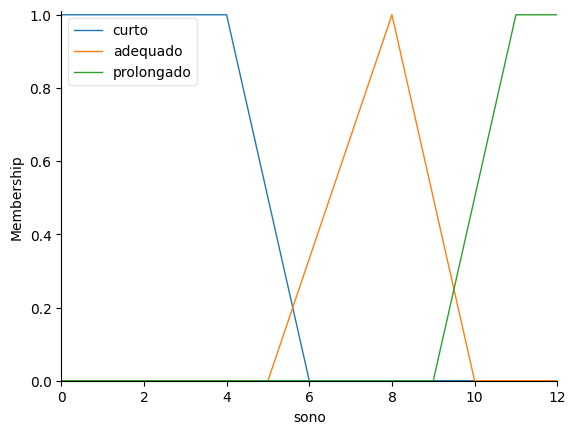

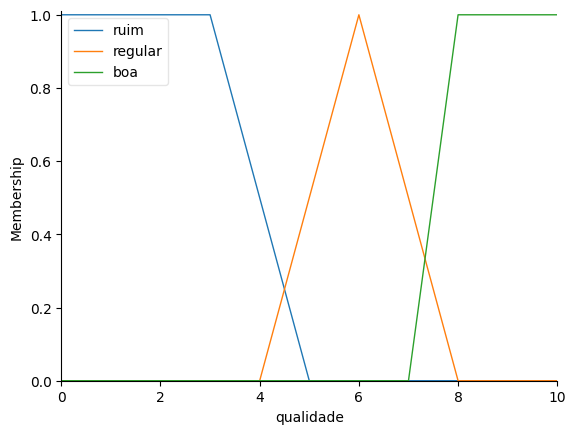

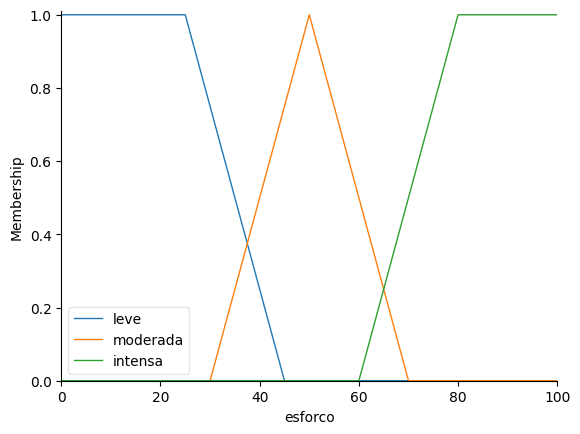

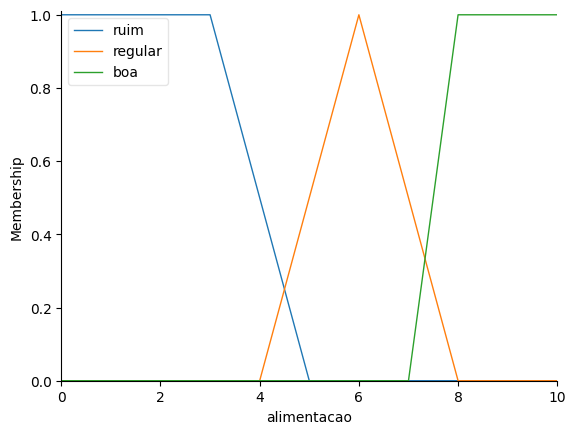

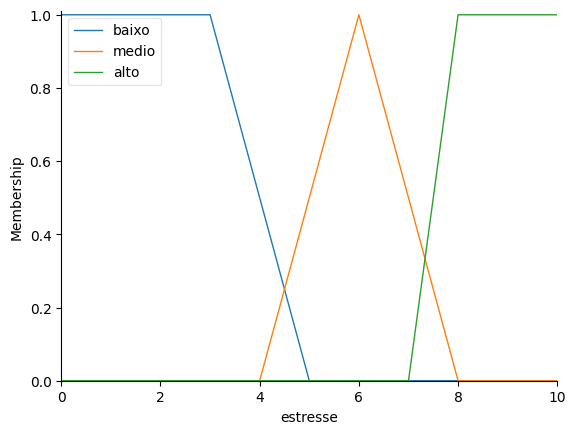

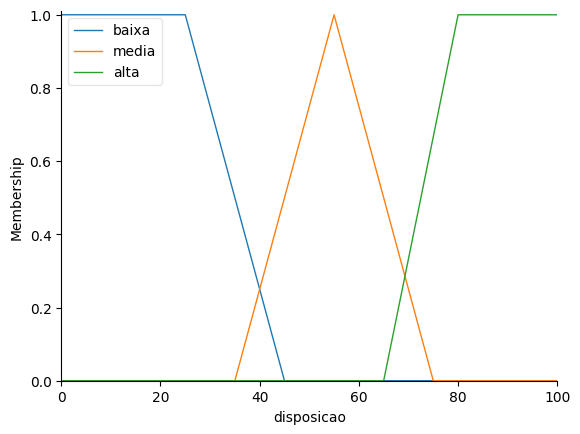

In [ ]:
# Visualização das funções de pertinência da V2
for var in [sono, qualidade, esforco, alimentacao, estresse, disposicao]:
    var.view()
    plt.show()

## V2 – Base de regras fuzzy

A cobertura **não é exaustiva** porque, com 5 entradas e 3 rótulos por entrada, haveria um número muito alto de combinações possíveis. Em vez de tentar cobrir tudo de forma artificial, o sistema prioriza:
- cenários extremos;
- rotinas boas;
- rotinas ruins;
- situações intermediárias;
- casos compensatórios, em que um fator ameniza outro.

Essa escolha é tecnicamente justificável porque o foco é representar os casos **mais semanticamente relevantes** para o problema.

In [ ]:
regras = [
    # Alta disposição
    ctrl.Rule(sono['adequado'] & qualidade['boa'] & alimentacao['boa'] & estresse['baixo'] & esforco['leve'], disposicao['alta']),
    ctrl.Rule(sono['adequado'] & qualidade['boa'] & alimentacao['boa'] & estresse['baixo'] & esforco['moderada'], disposicao['alta']),
    ctrl.Rule(sono['adequado'] & qualidade['regular'] & alimentacao['boa'] & estresse['baixo'], disposicao['alta']),
    ctrl.Rule(qualidade['boa'] & alimentacao['boa'] & estresse['baixo'] & esforco['leve'], disposicao['alta']),
    ctrl.Rule(sono['prolongado'] & qualidade['boa'] & alimentacao['boa'] & estresse['baixo'], disposicao['alta']),

    # Média disposição
    ctrl.Rule(sono['adequado'] & qualidade['regular'] & esforco['moderada'] & alimentacao['regular'] & estresse['medio'], disposicao['media']),
    ctrl.Rule(sono['curto'] & qualidade['boa'] & alimentacao['boa'] & estresse['baixo'], disposicao['media']),
    ctrl.Rule(sono['adequado'] & qualidade['boa'] & esforco['intensa'], disposicao['media']),
    ctrl.Rule(sono['prolongado'] & qualidade['regular'] & alimentacao['regular'], disposicao['media']),
    ctrl.Rule(estresse['medio'] & alimentacao['regular'] & qualidade['regular'], disposicao['media']),
    ctrl.Rule(sono['adequado'] & qualidade['regular'] & alimentacao['regular'] & estresse['baixo'], disposicao['media']),
    ctrl.Rule(sono['curto'] & qualidade['regular'] & esforco['leve'] & alimentacao['boa'], disposicao['media']),

    # Baixa disposição
    ctrl.Rule(sono['curto'] & qualidade['ruim'], disposicao['baixa']),
    ctrl.Rule(estresse['alto'] & alimentacao['ruim'], disposicao['baixa']),
    ctrl.Rule(sono['curto'] & esforco['intensa'], disposicao['baixa']),
    ctrl.Rule(qualidade['ruim'] & estresse['alto'], disposicao['baixa']),
    ctrl.Rule(alimentacao['ruim'] & estresse['alto'] & esforco['intensa'], disposicao['baixa']),
    ctrl.Rule(sono['curto'] & qualidade['ruim'] & estresse['alto'], disposicao['baixa']),
    ctrl.Rule(qualidade['ruim'] & alimentacao['ruim'], disposicao['baixa']),
    ctrl.Rule(estresse['alto'] & esforco['intensa'], disposicao['baixa'])
]

sistema = ctrl.ControlSystem(regras)

## V2 – Criação do sistema de inferência e função de simulação

In [ ]:
def simular_disposicao(sono_v, qualidade_v, esforco_v, alimentacao_v, estresse_v):
    simulador = ctrl.ControlSystemSimulation(sistema)
    simulador.input['sono'] = sono_v
    simulador.input['qualidade'] = qualidade_v
    simulador.input['esforco'] = esforco_v
    simulador.input['alimentacao'] = alimentacao_v
    simulador.input['estresse'] = estresse_v
    try:
        simulador.compute()
        return simulador.output['disposicao']
    except KeyError:
        return np.nan

## Dois cenários com inferência detalhada

A proposta pede duas inferências completas. Abaixo, além do resultado numérico final, mostramos o grau de pertinência das entradas e uma interpretação do comportamento esperado do sistema.

In [ ]:
def graus_pertinencia(variavel, valor, labels):
    return {label: float(fuzz.interp_membership(variavel.universe, variavel[label].mf, valor)) for label in labels}

def classificar_saida(valor):
    if pd.isna(valor):
        return "indefinida"
    if valor < 45:
        return "baixa"
    elif valor < 75:
        return "média"
    return "alta"

def analisar_cenario(nome, sono_v, qualidade_v, esforco_v, alimentacao_v, estresse_v):
    resultado = simular_disposicao(sono_v, qualidade_v, esforco_v, alimentacao_v, estresse_v)

    print(f"\n{nome}")
    print("-" * len(nome))
    print(f"Entradas: sono={sono_v}, qualidade={qualidade_v}, esforço={esforco_v}, alimentação={alimentacao_v}, estresse={estresse_v}")
    print("\nGraus de pertinência:")
    print("Sono:", graus_pertinencia(sono, sono_v, ['curto', 'adequado', 'prolongado']))
    print("Qualidade:", graus_pertinencia(qualidade, qualidade_v, ['ruim', 'regular', 'boa']))
    print("Esforço:", graus_pertinencia(esforco, esforco_v, ['leve', 'moderada', 'intensa']))
    print("Alimentação:", graus_pertinencia(alimentacao, alimentacao_v, ['ruim', 'regular', 'boa']))
    print("Estresse:", graus_pertinencia(estresse, estresse_v, ['baixo', 'medio', 'alto']))
    print(f"\nSaída defuzzificada: {resultado:.2f}" if not pd.isna(resultado) else "\nSaída defuzzificada: Indefinida")
    print(f"Classificação interpretada: {classificar_saida(resultado)}")

analisar_cenario("Cenário 1 – Rotina equilibrada", 8, 8, 35, 8, 2)
analisar_cenario("Cenário 2 – Rotina crítica", 4, 3, 85, 3, 9)


Cenário 1 – Rotina equilibrada
------------------------------
Entradas: sono=8, qualidade=8, esforço=35, alimentação=8, estresse=2

Graus de pertinência:
Sono: {'curto': 0.0, 'adequado': 1.0, 'prolongado': 0.0}
Qualidade: {'ruim': 0.0, 'regular': 0.0, 'boa': 1.0}
Esforço: {'leve': 0.5, 'moderada': 0.25, 'intensa': 0.0}
Alimentação: {'ruim': 0.0, 'regular': 0.0, 'boa': 1.0}
Estresse: {'baixo': 1.0, 'medio': 0.0, 'alto': 0.0}

Saída defuzzificada: 84.30
Classificação interpretada: alta

Cenário 2 – Rotina crítica
--------------------------
Entradas: sono=4, qualidade=3, esforço=85, alimentação=3, estresse=9

Graus de pertinência:
Sono: {'curto': 1.0, 'adequado': 0.0, 'prolongado': 0.0}
Qualidade: {'ruim': 1.0, 'regular': 0.0, 'boa': 0.0}
Esforço: {'leve': 0.0, 'moderada': 0.0, 'intensa': 1.0}
Alimentação: {'ruim': 1.0, 'regular': 0.0, 'boa': 0.0}
Estresse: {'baixo': 0.0, 'medio': 0.0, 'alto': 1.0}

Saída defuzzificada: 17.98
Classificação interpretada: baixa


## 40 cenários de teste documentados

A proposta exige pelo menos 40 cenários. A tabela abaixo já funciona como base para o **anexo de cenários e resultados**.

In [ ]:
cenarios = [
    ('01 Rotina excelente', 8, 9, 30, 9, 2),
    ('02 Boa rotina', 8, 8, 50, 8, 3),
    ('03 Sono curto + estresse alto', 4, 4, 40, 3, 9),
    ('04 Sono curto, mas alimentação boa', 5, 8, 35, 8, 4),
    ('05 Muito esforço', 7, 7, 90, 7, 4),
    ('06 Estresse alto', 8, 7, 40, 7, 9),
    ('07 Alimentação ruim', 8, 8, 35, 2, 4),
    ('08 Qualidade ruim', 8, 3, 35, 8, 3),
    ('09 Sono prolongado', 11, 7, 30, 7, 2),
    ('10 Rotina mediana', 7, 6, 50, 6, 6),
    ('11 Sono curto extremo', 2, 2, 60, 3, 8),
    ('12 Baixo esforço e boa rotina', 8, 8, 20, 8, 2),
    ('13 Qualidade boa, mas estresse médio', 8, 8, 45, 8, 6),
    ('14 Alimentação regular', 8, 8, 40, 6, 3),
    ('15 Esforço intenso e sono adequado', 8, 8, 85, 8, 3),
    ('16 Estresse médio', 8, 7, 40, 8, 6),
    ('17 Rotina contraditória 1', 5, 9, 80, 9, 8),
    ('18 Rotina contraditória 2', 10, 4, 20, 8, 2),
    ('19 Rotina contraditória 3', 6, 7, 30, 3, 8),
    ('20 Rotina contraditória 4', 9, 5, 70, 8, 3),
    ('21 Sono adequado e alimentação boa', 8, 7, 45, 9, 3),
    ('22 Qualidade ruim e estresse alto', 7, 2, 50, 5, 9),
    ('23 Sono curto e baixa qualidade', 4, 3, 30, 5, 5),
    ('24 Sono bom, mas alimentação ruim', 8, 8, 35, 2, 3),
    ('25 Rotina quase ideal', 8, 9, 25, 9, 1),
    ('26 Rotina ruim geral', 4, 3, 85, 2, 9),
    ('27 Sono prolongado e esforço leve', 11, 8, 20, 8, 2),
    ('28 Estresse alto, mas boa alimentação', 8, 8, 35, 9, 8),
    ('29 Sono adequado e esforço moderado', 8, 7, 55, 7, 4),
    ('30 Qualidade regular e estresse médio', 7, 6, 45, 6, 6),
    ('31 Alimentação boa e esforço intenso', 8, 8, 90, 9, 4),
    ('32 Sono curto compensado parcialmente', 5, 8, 20, 8, 2),
    ('33 Sono bom e estresse muito alto', 8, 8, 30, 8, 10),
    ('34 Muito cansativo', 6, 6, 100, 5, 7),
    ('35 Muito descanso, pouca qualidade', 11, 3, 20, 6, 4),
    ('36 Moderado em tudo', 7, 6, 50, 6, 5),
    ('37 Bom sono, esforço leve, alimentação regular', 8, 8, 25, 6, 3),
    ('38 Baixa qualidade geral', 6, 4, 60, 4, 7),
    ('39 Rotina quase crítica', 4, 4, 80, 3, 8),
    ('40 Rotina saudável com estresse baixo', 8, 8, 35, 8, 2)
]

resultados = []
for nome, s, q, e, a, est in cenarios:
    valor = simular_disposicao(s, q, e, a, est)
    resultados.append([nome, s, q, e, a, est, round(valor, 2), classificar_saida(valor)])

df_resultados = pd.DataFrame(
    resultados,
    columns=['cenario', 'sono', 'qualidade', 'esforco', 'alimentacao', 'estresse', 'disposicao', 'classe']
)

df_resultados

,cenario,sono,qualidade,esforco,alimentacao,estresse,disposicao,classe
1,01 Rotina excelente,8,9,30,9,2,85.13,alta
2,02 Boa rotina,8,8,50,8,3,85.91,alta
3,03 Sono curto + estresse alto,4,4,40,3,9,17.98,baixa
4,"04 Sono curto, mas alimentação boa",5,8,35,8,4,69.96,média
5,05 Muito esforço,7,7,90,7,4,55.00,média
6,06 Estresse alto,8,7,40,7,9,NaN,indefinida
7,07 Alimentação ruim,8,8,35,2,4,NaN,indefinida
8,08 Qualidade ruim,8,3,35,8,3,NaN,indefinida
9,09 Sono prolongado,11,7,30,7,2,55.00,média
10,10 Rotina mediana,7,6,50,6,6,55.00,média


In [ ]:
# Resumo por classe
df_resultados['classe'].value_counts()

,count
classe,
indefinida,12
média,10
baixa,9
alta,9


## Comparação entre V1 e V2

### V1
- 3 entradas: sono, qualidade e esforço;
- modelo mais simples;
- útil para validar a ideia inicial;
- menor capacidade de representar fatores emocionais e hábitos alimentares.

### V2
- 5 entradas: sono, qualidade, esforço, alimentação e estresse;
- mais aderente à realidade;
- representa compensações e contradições com mais fidelidade;
- melhora a interpretação do problema.

### O que mudou e por quê
A V2 foi criada para **corrigir a simplificação excessiva da V1**. Ao adicionar alimentação e estresse, o sistema passou a representar melhor o cotidiano real das pessoas, o que torna a modelagem mais defensável.

## Interpretação crítica e limitações

- O modelo continua sendo uma **aproximação** da realidade, não um diagnóstico.
- Algumas variáveis são subjetivas, especialmente qualidade do sono, alimentação e estresse.
- Pequenas mudanças nas funções de pertinência podem alterar os resultados, o que mostra a **sensibilidade do sistema**.
- A cobertura de regras não é total; ela foi orientada por relevância semântica.
- O sistema não considera fatores médicos, emocionais complexos, uso de medicamentos ou doenças.

## Conclusão

O sistema fuzzy desenvolvido atende ao objetivo de estimar a disposição humana a partir de múltiplos fatores do cotidiano. A modelagem fuzzy mostrou-se adequada por lidar bem com gradações, subjetividade e ambiguidades. A evolução da **V1 para a V2** tornou o modelo mais realista e defensável. Além disso, os 40 cenários documentados ajudam a sustentar a análise crítica exigida pela proposta.

## Referências

Vos Gideon, Trinh Kelly, Sarnyai Zoltan, Azghadi Rahimi Mostafa, **Generalizable Machine Learning for Stress Monitoring from Wearable Devices: A Systematic Literature Review**, International Journal of Medical Informatics Volume 173, disponível em https://arxiv.org/pdf/2209.15137.

Ortega Natalia, Tennant WG Peter, Greenwood C Darren, Pano Octavio, **Meta-Analyses of Dietary Exposures Must Consider Energy Adjustment: Recommendations From a Meta-Scientific Review**, disponível em https://arxiv.org/pdf/2512.07531.

Cañellas Lage Manuel, Casado Alvarez Constantino, Nguyen Le, Lopez Bordallo Miguel, **Estimating Exercise-Induced Fatigue From Thermal Facial**, disponível em https://arxiv.org/pdf/2309.06095.

Althoff Tim, Horvitz Eric, White W. Ryen, Zeitzer Jamie, **Harnessing the Web for Population-Scale Physiological Sensing: A Case Study of Sleep and Performance**, disponível em https://arxiv.org/pdf/1701.07083